YASMINE

In [31]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [32]:
df = pd.read_csv("tmdb_5000_movies.csv")
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [33]:
df = df[['budget', 'revenue', 'popularity', 'runtime', 'vote_average']]
df.head()

,budget,revenue,popularity,runtime,vote_average
0,237000000,2787965087,150.437577,162.0,7.2
1,300000000,961000000,139.082615,169.0,6.9
2,245000000,880674609,107.376788,148.0,6.3
3,250000000,1084939099,112.312950,165.0,7.6
4,260000000,284139100,43.926995,132.0,6.1


In [35]:
df = df.dropna()

df = df[
    (df['budget'] > 0) &
    (df['revenue'] > 0) &
    (df['runtime'] > 0)
]

print(df.shape)
df.head()

(3229, 5)


,budget,revenue,popularity,runtime,vote_average
0,237000000,2787965087,150.437577,162.0,7.2
1,300000000,961000000,139.082615,169.0,6.9
2,245000000,880674609,107.376788,148.0,6.3
3,250000000,1084939099,112.312950,165.0,7.6
4,260000000,284139100,43.926995,132.0,6.1


In [37]:
median_revenue = df['revenue'].median()

df['success'] = (df['revenue'] > median_revenue).astype(int)

df[['revenue', 'success']].head()
print(df['success'].value_counts())

success
0    1615
1    1614
Name: count, dtype: int64


In [38]:
print(df['success'].value_counts())

success
0    1615
1    1614
Name: count, dtype: int64


In [39]:
X = df[['budget', 'popularity', 'runtime', 'vote_average']]
y = df['success']

print(X.head())
print(y.head())

      budget  popularity  runtime  vote_average
0  237000000  150.437577    162.0           7.2
1  300000000  139.082615    169.0           6.9
2  245000000  107.376788    148.0           6.3
3  250000000  112.312950    165.0           7.6
4  260000000   43.926995    132.0           6.1
0    1
1    1
2    1
3    1
4    1
Name: success, dtype: int64


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(2583, 4)
(646, 4)


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

y_pred = baseline_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8018575851393189
Precision: 0.8239202657807309
Recall: 0.7678018575851393
F1-score: 0.7948717948717948

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.84      0.81       323
           1       0.82      0.77      0.79       323

    accuracy                           0.80       646
   macro avg       0.80      0.80      0.80       646
weighted avg       0.80      0.80      0.80       646

Confusion Matrix:

[[270  53]
 [ 75 248]]


ANNIKA

In [44]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [46]:
#model
nn_model = Sequential()

nn_model.add(Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)))
nn_model.add(Dense(8, activation='relu'))
nn_model.add(Dense(1, activation='sigmoid'))

In [47]:
nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

In [48]:
#train
history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2)

Epoch 1/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5862 - loss: 0.6529 - val_accuracy: 0.6925 - val_loss: 0.5874
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7236 - loss: 0.5856 - val_accuracy: 0.7369 - val_loss: 0.5304
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7483 - loss: 0.5318 - val_accuracy: 0.7737 - val_loss: 0.4841
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7604 - loss: 0.4917 - val_accuracy: 0.7834 - val_loss: 0.4526
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7667 - loss: 0.4676 - val_accuracy: 0.7969 - val_loss: 0.4323
Epoch 6/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7783 - loss: 0.4541 - val_accuracy: 0.8046 - val_loss: 0.4200
Epoch 7/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7875 - loss: 0.4440 - val_accuracy: 0.8066 - val_loss: 0.4094
Epoch 8/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7933 - loss: 0.4388 - val_accuracy: 0.8104 - val_loss:

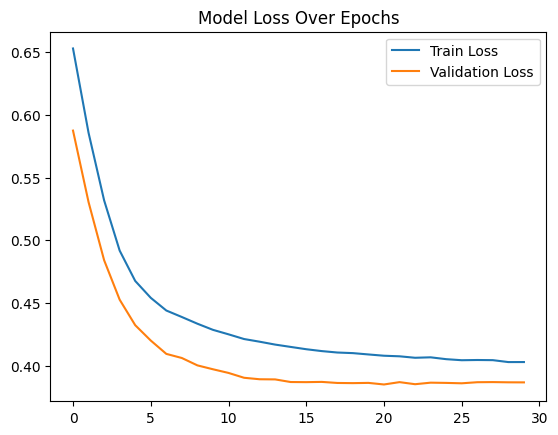

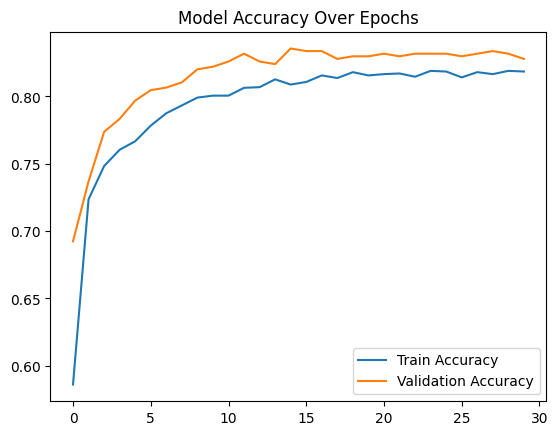

In [49]:
#accuracy curve
import matplotlib.pyplot as plt

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss Over Epochs")
plt.show()

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy Over Epochs")
plt.show()

In [50]:
#predictions
y_pred_prob_nn = nn_model.predict(X_test_scaled)
y_pred_nn = (y_pred_prob_nn > 0.5).astype(int)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [51]:
#eval
print("Neural Network Performance:")

print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print("Precision:", precision_score(y_test, y_pred_nn))
print("Recall:", recall_score(y_test, y_pred_nn))
print("F1 Score:", f1_score(y_test, y_pred_nn))

Neural Network Performance:
Accuracy: 0.8235294117647058
Precision: 0.8381877022653722
Recall: 0.8018575851393189
F1 Score: 0.819620253164557


In [52]:
# Tuned Neural Network Model
tuned_model = Sequential()

tuned_model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
tuned_model.add(Dense(16, activation='relu'))
tuned_model.add(Dense(1, activation='sigmoid'))

tuned_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

tuned_history = tuned_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6980 - loss: 0.6153 - val_accuracy: 0.7466 - val_loss: 0.5477
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7686 - loss: 0.5113 - val_accuracy: 0.7892 - val_loss: 0.4576
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7885 - loss: 0.4558 - val_accuracy: 0.8085 - val_loss: 0.4156
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7982 - loss: 0.4336 - val_accuracy: 0.8182 - val_loss: 0.3992
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8001 - loss: 0.4255 - val_accuracy: 0.8182 - val_loss: 0.3944
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8035 - loss: 0.4213 - val_accuracy: 0.8221 - val_loss: 0.3927
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8054 - loss: 0.4179 - val_accuracy: 0.8279 - val_loss: 0.3926
Epoch 8/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8093 - loss: 0.4168 - val_accuracy: 0.8240 - val_loss: 0.3900
E

In [55]:
#eval tuned model
y_pred_prob_tuned = tuned_model.predict(X_test_scaled)
y_pred_tuned = (y_pred_prob_tuned > 0.5).astype(int)

print("Tuned Neural Network Performance:")

print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("F1 Score:", f1_score(y_test, y_pred_tuned))

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Tuned Neural Network Performance:
Accuracy: 0.8111455108359134
Precision: 0.845360824742268
Recall: 0.7616099071207431
F1 Score: 0.8013029315960912


In [56]:
#compare
print("Baseline vs Neural Network")

print("\nBaseline Model:")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nNeural Network:")
print("Accuracy:", accuracy_score(y_test, y_pred_nn))

Baseline vs Neural Network

Baseline Model:
Accuracy: 0.8018575851393189

Neural Network:
Accuracy: 0.8235294117647058


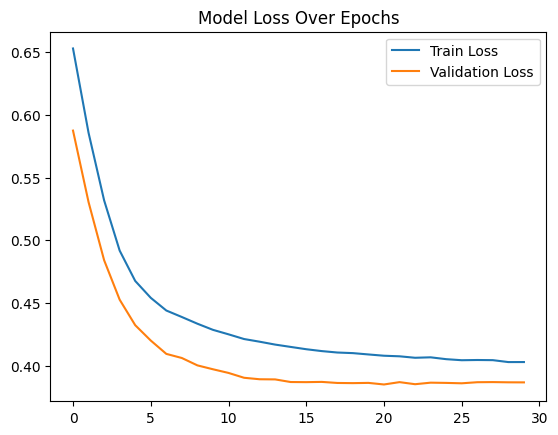

In [57]:
#training curve
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss Over Epochs")
plt.show()

In [58]:
#compare all models
print("Final Model Comparison")

print("\nBaseline (Logistic Regression):")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nNeural Network:")
print("Accuracy:", accuracy_score(y_test, y_pred_nn))

print("\nTuned Neural Network:")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))

Final Model Comparison

Baseline (Logistic Regression):
Accuracy: 0.8018575851393189

Neural Network:
Accuracy: 0.8235294117647058

Tuned Neural Network:
Accuracy: 0.8111455108359134
